<h1>Assignment: Gaussian Mixture Models Clustering</h1>
    The purpose of this assignment is to apply Gaussian Mixture Models (GMM) for clustering tasks using two different Datasets. You will work with a synthetic dataset to understand the practical application of GMM and its implementation in Python. In addition, you will wirk with PCA as a feature extraction method to cluster MNIST digits (0,1,4):

 <h2>Exercise 1: Clustering with synthetic data and <code>sklearn</code></h2>  
 <h2>Dataset:</h2>
    <p>You will generate a synthetic dataset using <code>sklearn.datasets.make_blobs</code> function with predefined parameters .</p>

 <h3>Data Preparation:</h3>
    <ol>
        <li>Generate a synthetic dataset using <code>sklearn.datasets.make_blobs</code> with <code>n_samples=300</code>, <code>centers=4</code>, <code>cluster_std=0.60</code>, and <code>random_state=0</code>.</li>
        <li>Plot the dataset to visualize the clusters.</li>
    </ol>

 <h3>GMM Clustering:</h3>
    <ol start="3">
        <li>Use the <code>sklearn.mixture.GaussianMixture</code> class to fit the model with <code>n_components=4</code> and <code>random_state=0</code>.</li>
        <li>Predict the cluster labels for the dataset and plot the results showing each cluster with a different color.</li>
    </ol>

 <h3>Analysis:</h3>
    <ol start="5">
        <li>Report the means and covariances of the clusters.</li>
        <li>Discuss the shape and orientation of the clusters based on the covariance matrices.</li>
    </ol>


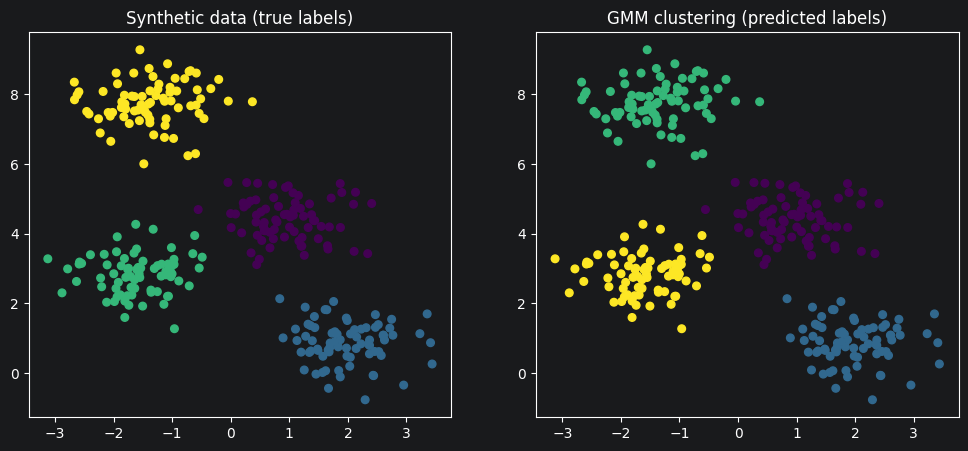

Means:
[[ 0.93842466  4.41564635]
 [ 1.98299679  0.86735608]
 [-1.37355181  7.75436785]
 [-1.58913964  2.82465347]]

Covariances:
[[[ 0.3808649  -0.02231979]
  [-0.02231979  0.34881473]]

 [[ 0.33998651 -0.02620931]
  [-0.02620931  0.34588507]]

 [[ 0.41216925  0.02884065]
  [ 0.02884065  0.37959193]]

 [[ 0.32360185  0.01027908]
  [ 0.01027908  0.30862196]]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

# Exercise 1: synthetic data + GMM
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
gmm = GaussianMixture(n_components=4, random_state=0)
gmm.fit(X)
labels = gmm.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, s=30, cmap='viridis')
axes[0].set_title('Synthetic data (true labels)')
axes[1].scatter(X[:, 0], X[:, 1], c=labels, s=30, cmap='viridis')
axes[1].set_title('GMM clustering (predicted labels)')
plt.show()

print('Means:')
print(gmm.means_)
print('\nCovariances:')
print(gmm.covariances_)

 <h2>Exercise 1: Dimensionality Reduction and Clustering with MNIST</h2>  

<p>This assignment explores dimensionality reduction with Principal Component Analysis (PCA) and clustering using Gaussian Mixture Models (GMM) on a subset of the MNIST dataset. The goal is to understand the impact of PCA on data visualization and clustering accuracy.</p>
        
 <h2>Dataset:</h2>
        <p>You will use the MNIST dataset, focusing specifically on the digits 0, 1, and 4. Your tasks involve data preparation, dimensionality reduction, PCA component analysis, and clustering.</p>
        
<h2>Tasks:</h2>
<ol>
 <li><strong>Data Preparation:</strong>
 <ul>
     <li>Load the MNIST dataset.</li>
                    <li>Normalize the data to have values between 0 and 1.</li>
                    <li>Filter the dataset for digits 0, 1, and 4 only.</li>
                    <li>Visualize the first few images of the filtered dataset.</li>
                </ul>
            </li>
    <li><strong>Dimensionality Reduction with PCA:</strong>
                <ul>
                    <li>Apply PCA to reduce the data to 2 features.</li>
                    <li>Visualize the scatter plot of the reduced data.</li>
                    <li>Reconstruct images from the reduced data and compare with original images.</li>
                </ul>
            </li>
<li><strong>Exploring PCA Components:</strong>
                <ul>
                    <li>Visualize the first two principal components as images.</li>
                    <li>Plot the explained variance ratio of the PCA components.</li>
                </ul>
            </li>
 <li><strong>Clustering with Gaussian Mixture Models:</strong>
                <ul>
                    <li>Apply GMM to cluster the reduced data into three clusters.</li>
                    <li>Visualize the clustering results with a scatter plot.</li>
                    <li>Compare the clustering results with the true labels.</li>
                </ul>
            </li>
        </ol>
        


Filtered dataset shape: (21604, 784)


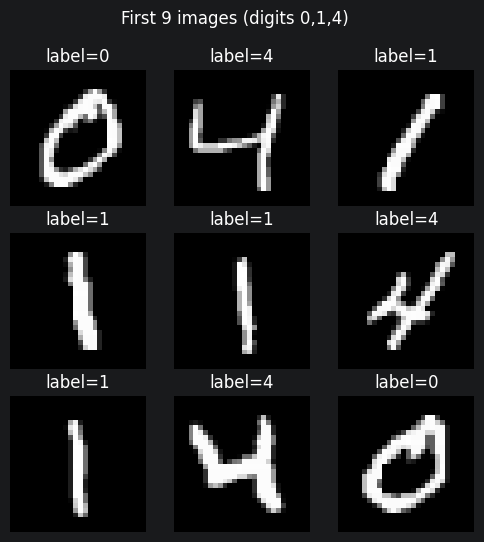

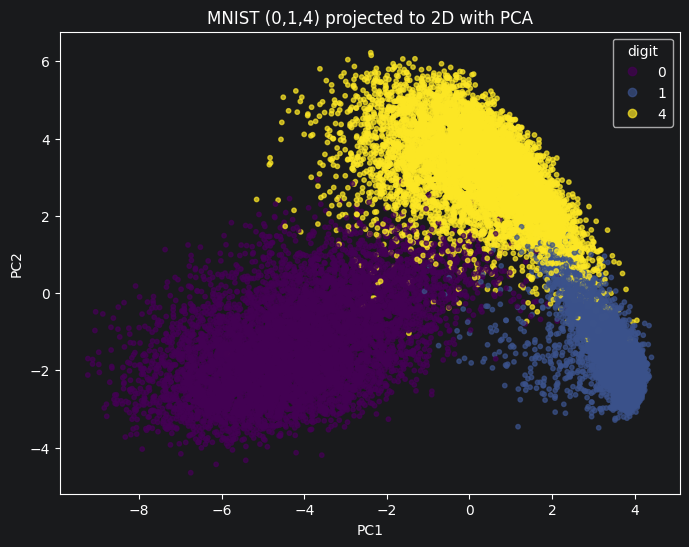

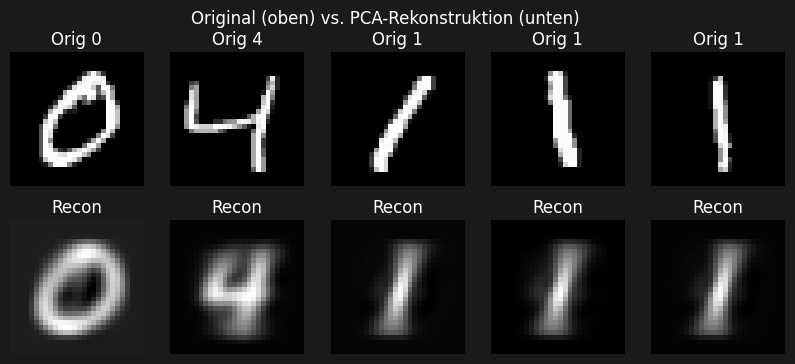

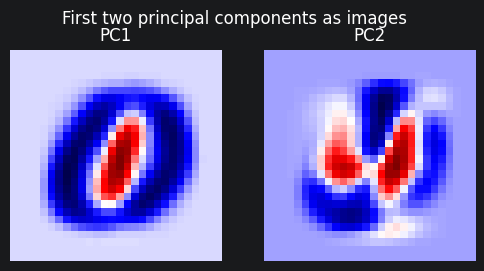

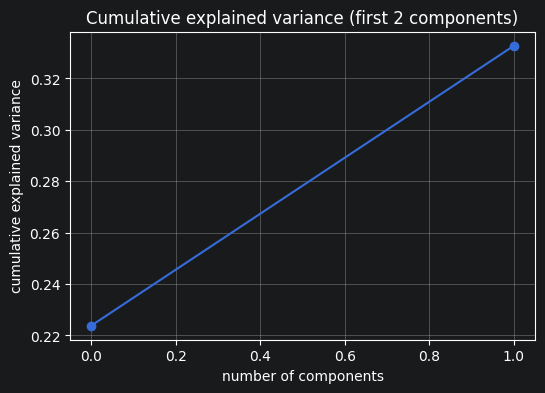

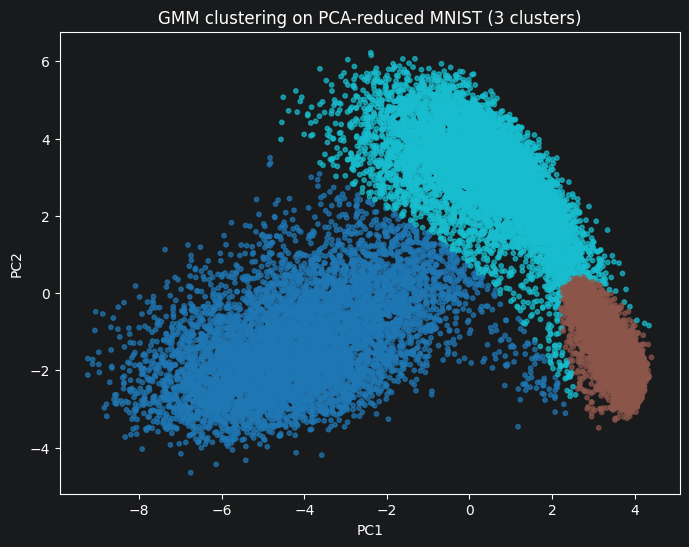

Adjusted Rand Index (ARI) between true labels and GMM clusters: 0.9021670519472036
Cluster-majority-mapped accuracy (approx): 0.9664413997407888


In [2]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from collections import Counter

# Exercise 2: PCA + GMM on MNIST (digits 0,1,4)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_all = mnist['data'] / 255.0
y_all = mnist['target'].astype(int)
mask = (y_all == 0) | (y_all == 1) | (y_all == 4)
X = X_all[mask]
y = y_all[mask]

print('Filtered dataset shape:', X.shape)

# show first 9 images
fig, axs = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axs.ravel()):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'label={y[i]}')
    ax.axis('off')
plt.suptitle('First 9 images (digits 0,1,4)')
plt.show()

# PCA to 2 components
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=10, alpha=0.7)
plt.legend(*scatter.legend_elements(), title='digit')
plt.title('MNIST (0,1,4) projected to 2D with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# reconstruct examples
X_inv = pca.inverse_transform(X_pca)
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axs[0, i].imshow(X[i].reshape(28, 28), cmap='gray')
    axs[0, i].set_title(f'Orig {y[i]}')
    axs[0, i].axis('off')
    axs[1, i].imshow(X_inv[i].reshape(28, 28), cmap='gray')
    axs[1, i].set_title('Recon')
    axs[1, i].axis('off')
plt.suptitle('Original (oben) vs. PCA-Rekonstruktion (unten)')
plt.show()

# show first two principal components as images
pc1 = pca.components_[0].reshape(28, 28)
pc2 = pca.components_[1].reshape(28, 28)
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1); plt.imshow(pc1, cmap='seismic'); plt.title('PC1'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(pc2, cmap='seismic'); plt.title('PC2'); plt.axis('off')
plt.suptitle('First two principal components as images')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Cumulative explained variance (first 2 components)')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.grid(True)
plt.show()

# GMM on PCA-reduced data
gmm_mnist = GaussianMixture(n_components=3, random_state=0)
gmm_mnist.fit(X_pca)
labels_gmm = gmm_mnist.predict(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap='tab10', s=10, alpha=0.7)
plt.title('GMM clustering on PCA-reduced MNIST (3 clusters)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

ari = adjusted_rand_score(y, labels_gmm)
print('Adjusted Rand Index (ARI) between true labels and GMM clusters:', ari)

# majority mapping for interpretability
cluster_to_label = {}
for c in np.unique(labels_gmm):
    idx = np.where(labels_gmm == c)[0]
    most_common = Counter(y[idx]).most_common(1)[0][0]
    cluster_to_label[c] = most_common

predicted_labels_mapped = np.vectorize(cluster_to_label.get)(labels_gmm)
accuracy = (predicted_labels_mapped == y).mean()
print('Cluster-majority-mapped accuracy (approx):', accuracy)
